In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("train.csv")
df1=pd.read_csv("test.csv")

In [3]:
df=pd.concat([df,df1],axis=0)

In [4]:
df.shape

(505207, 12)

In [5]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 505207 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 50.1+ MB


In [7]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [10]:
df.shape

(505206, 12)

In [11]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


[]

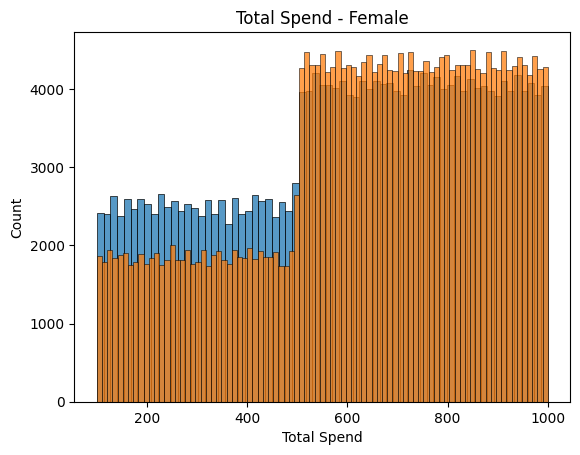

In [12]:
sns.histplot(df[df['Gender']=="Female"]['Total Spend'])
sns.histplot(df[df['Gender']=="Male"]['Total Spend'])

plt.title("Total Spend - Female")
plt.plot()

[]

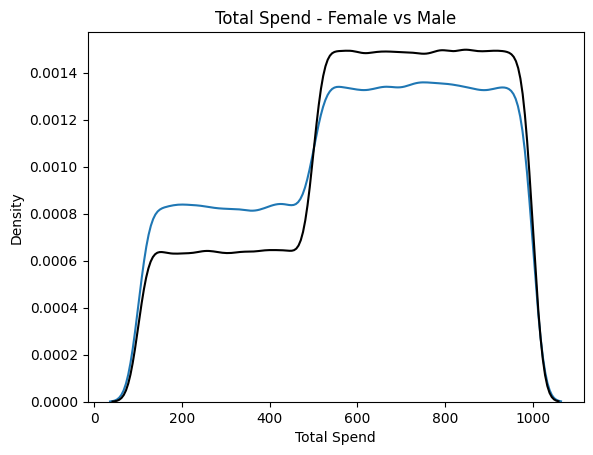

In [13]:
sns.kdeplot(df[df['Gender']=="Female"]['Total Spend'])
sns.kdeplot(df[df['Gender']=="Male"]['Total Spend'],color="Black")

plt.title("Total Spend - Female vs Male")
plt.plot()

In [14]:
#The Data isnt normally distributed.
#The avg spend of male is greater than that of a female.

<Axes: xlabel='Total Spend', ylabel='Density'>

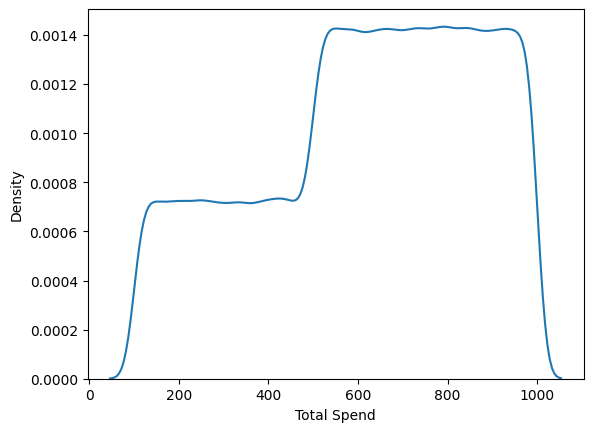

In [15]:
sns.kdeplot(df['Total Spend'])

In [16]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


<Axes: xlabel='Age', ylabel='Density'>

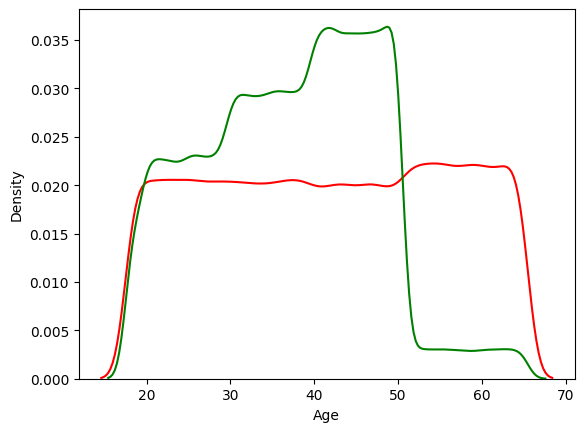

In [17]:
sns.kdeplot(df[df["Churn"]==1]["Age"],color="Red")
sns.kdeplot(df[df["Churn"]==0]["Age"],color="Green")
            

In [18]:
(df.groupby("Gender")["Churn"].value_counts())

Gender  Churn
Female  1.0      145969
        0.0       78964
Male    0.0      145750
        1.0      134523
Name: count, dtype: int64

In [19]:
df["Churn"].value_counts()

Churn
1.0    280492
0.0    224714
Name: count, dtype: int64

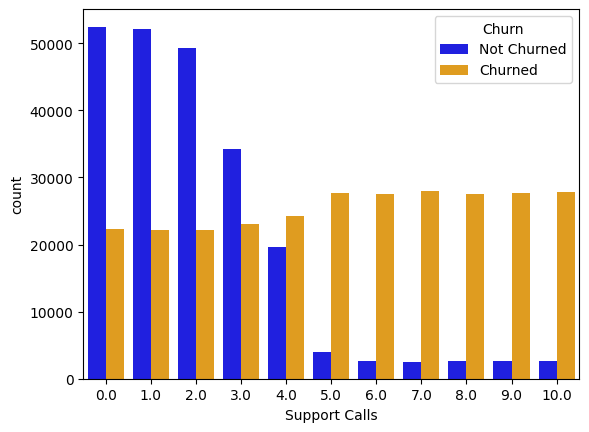

In [20]:
sns.countplot(data=df, x='Support Calls', hue='Churn', 
              palette={0.0: 'blue', 1.0: 'orange'})
plt.legend(title='Churn', labels=['Not Churned', 'Churned'])
plt.show()

In [21]:
#from the plot we understood that after 4 support calls, the customers who churned dominates the no. of customers who didnt churned.

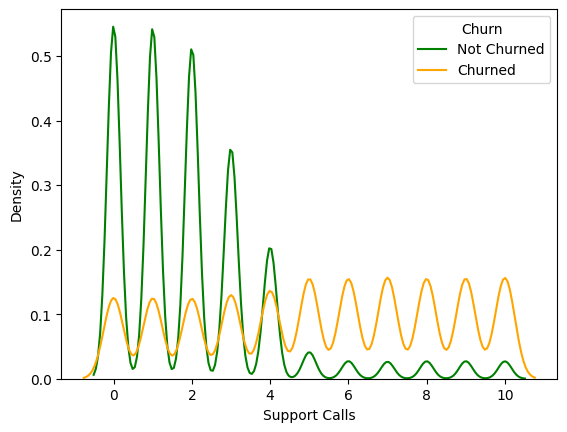

In [22]:
sns.kdeplot(df[df["Churn"]==0]["Support Calls"] ,color="Green")
sns.kdeplot(df[df["Churn"]==1]["Support Calls"], color="Orange")
plt.legend(title="Churn",labels=["Not Churned","Churned"])
plt.show()

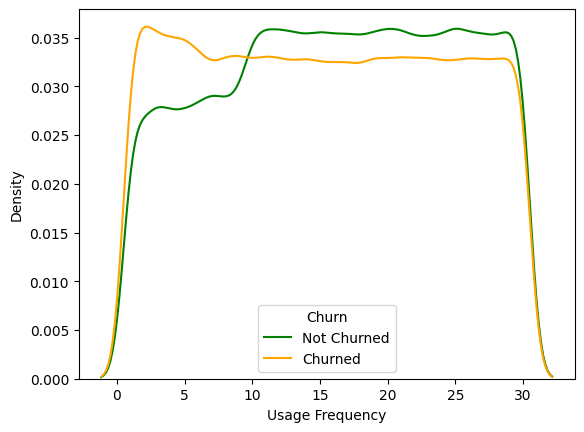

In [23]:
sns.kdeplot(df[df["Churn"]==0]["Usage Frequency"] ,color="Green")
sns.kdeplot(df[df["Churn"]==1]["Usage Frequency"], color="Orange")
plt.legend(title="Churn",labels=["Not Churned","Churned"])
plt.show()

In [24]:
#customers with less usage(0-10) are more like to churn
#customers with more usage (<10) are more likely to NOT churn

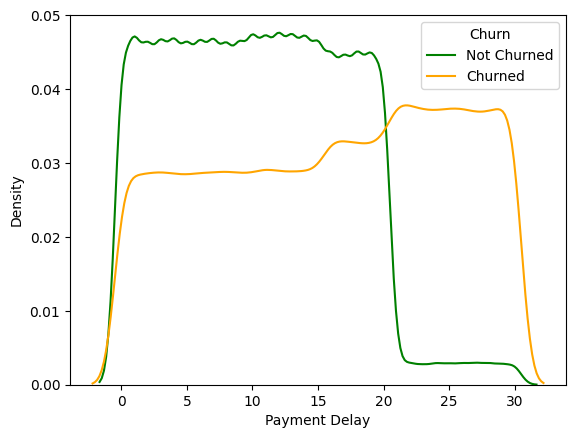

In [25]:
sns.kdeplot(df[df["Churn"]==0]["Payment Delay"] ,color="Green")
sns.kdeplot(df[df["Churn"]==1]["Payment Delay"], color="Orange")
plt.legend(title="Churn",labels=["Not Churned","Churned"])
plt.show()

In [26]:
#Customer who dont churn have payment delay of about 20 days
#Customers who churn have payment delay of about 30 days


In [27]:
df.sample()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
52165,53056.0,46.0,Female,42.0,11.0,1.0,8.0,Premium,Quarterly,328.0,20.0,1.0


In [28]:
(df.groupby("Subscription Type")["Total Spend"].mean())

Subscription Type
Basic       617.227238
Premium     621.675034
Standard    621.218400
Name: Total Spend, dtype: float64

In [29]:
#: Subscription Type and Total Spend are not strongly related to each other

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder




In [31]:
df["Contract Length"].value_counts()

Contract Length
Annual       198608
Quarterly    197364
Monthly      109234
Name: count, dtype: int64

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

ct = ColumnTransformer(
    transformers=[
        ('tnf1', StandardScaler(), 
         ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 
          'Payment Delay', 'Total Spend', 'Last Interaction']),
        ('tnf2', OneHotEncoder(sparse_output=False, drop='first'), 
         ['Gender', 'Subscription Type']),
        ('tnf3', OrdinalEncoder(categories=[['Monthly', 'Quarterly', 'Annual']]), 
         ['Contract Length'])
    ],
    remainder='passthrough'
)

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(["Churn",'CustomerID'], axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

pipe = Pipeline(steps=[
    ('preprocessor', ct),
    ('model', LogisticRegression(class_weight="balanced"))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

In [56]:
print(X_train.columns.tolist())

['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']


In [64]:
y_pred

array([1., 1., 0., ..., 0., 1., 0.], shape=(101042,))

In [65]:
from sklearn.metrics import f1_score, classification_report

print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

F1 Score: 0.8398117934164672
              precision    recall  f1-score   support

         0.0       0.78      0.85      0.82     44943
         1.0       0.87      0.81      0.84     56099

    accuracy                           0.83    101042
   macro avg       0.83      0.83      0.83    101042
weighted avg       0.83      0.83      0.83    101042



In [66]:
print(pipe.score(X_train, y_train))
print(pipe.score(X_test, y_test))

0.8280450510188934
0.8284970606282536
